### Kaggle Competition Try-Out with Titanic Dataset

im planning to use logistic regresion with Pytorch or scikit-learn

##### no asking AI about how to process, choose, and build the model challenge

In [1]:
import random
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

### Data Preprocessing
I will do things as data cleaning, and feature engineering to transform normal readable data to something that the model can understand better

In [2]:
dataset = pd.read_csv("train.csv")
print(dataset)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

- PassengerId = id of each passenger in the dataset (unique numbers)
- Survived = value telling passenger survived or not (0 / 1)
- Pclass = ticket class, socio economic status (1 = upper / 2 = middle / 3 = lower)
- Name = name of person in the ship, complete with their honorifics (unique strings)
- Sex = sex of the person in the ship (male / female)
- Age = age of the person in the ship (number between 0.42 - 80)
- SibSp = count of sibling and spouse the passenger with (number between 0 - 8)
- Parch = count of parent and child the passeger with (number between 0 - 6)
- Ticket = passenger ticket id (unique strings)
- Fare = how many did the passanger pay (number between 0 - 512)

lets work our way to fixing each columns first! 
For passengerId, we dont need that since it doesnt represent something meaningful for the model.
For survived, its gonna be as it is for the ground truth.
For Pclass, im gonna keep it as it is because the number already good enough for a model and can be used to other purposes. 
For the name, since it is unique string that we cant use, i see that many people has honorific in their name so lets pull that out so we can use it for any purpose later.

In [3]:
names = dataset[["Name"]]
honorifics = ["Mr.", "Mrs.", "Miss.", "Master.", "Don.", "Rev.", "Dr.", "Mme.", "Major.", "Lady.", "Ms.", "Sir.", "Mlle.", "Col.", "Capt.", "Countess.", "Jonkheer."]

pattern = "(" + "|".join(h.replace(".", r"\.") for h in honorifics) + ")"

honorifics_only_names = names["Name"].str.extract(pattern)[0].str.strip(".")
print(honorifics_only_names)

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: 0, Length: 891, dtype: str


okay, now lets convert sex to 0 and 1, where 0 is female and 1 is male

In [4]:
sex = dataset["Sex"].replace("male", 1).replace("female", 0)
print(sex.value_counts())

Sex
1    577
0    314
Name: count, dtype: int64


Lets move on to Age. The age is a little bit tricky because there is a bunch of missing value. 
Rather than putting 0, we can make a prediction according to the honorific in their name that we pull earlier!

In [5]:
# im putting variable after loop here so the result is saved in memory
min_max_age = []


In [6]:
honorifics = ["Mr.", "Mrs.", "Miss.", "Master.", "Don.", "Rev.", "Dr.", "Mme.", "Major.", "Lady.", "Ms.", "Sir.", "Mlle.", "Col.", "Capt.", "Countess.", "Jonkheer."]

pd_hon_names = pd.DataFrame({'Honorifics': honorifics_only_names})["Honorifics"]
age = dataset["Age"]
age_hon = pd.DataFrame([age, pd_hon_names])
np_age_hon = age_hon.to_numpy().transpose()

for honorific in honorifics:
    honorific = honorific.strip(".")
    
    min_val = 0
    max_val = 0
    
    for row_index in range(np_age_hon.shape[0]):
        row_honorific = np_age_hon[row_index][1]        
                
        if row_honorific == honorific:
            age_val = np_age_hon[row_index][0]
            
            min_val = age_val if age_val < min_val or min_val == 0 else min_val
            max_val = age_val if age_val > max_val or max_val == 0 else max_val

    min_max_age.append([min_val, max_val])
    
print(min_max_age)

[[11.0, 80.0], [14.0, 63.0], [0.75, 63.0], [0.42, 12.0], [40.0, 40.0], [27.0, 57.0], [23.0, 54.0], [24.0, 24.0], [45.0, 52.0], [48.0, 48.0], [28.0, 28.0], [49.0, 49.0], [24.0, 24.0], [56.0, 60.0], [70.0, 70.0], [33.0, 33.0], [38.0, 38.0]]


WOAH, i see that miss. honorific cover the entire range from a child to a very old people. Different from male that has master. honorific for a child and mr. for unmarried. 

i will split miss. honorific into a new syntetic honorific if the age is below the maximum age of master. (male that is considered as a child)

In [7]:
syntetic_honorific = "Masis"

honorifics.append(syntetic_honorific + ".")

age_hon = age_hon.transpose()

mask = (age_hon['Honorifics'] == "Miss") & (age_hon['Age'] <= min_max_age[3][1])
age_hon.loc[mask, "Honorifics"] = syntetic_honorific

np_age_hon = age_hon.to_numpy()

## do the operation again
min_max_age = []

for honorific in honorifics:
    honorific = honorific.strip(".")
    
    min_val = 0
    max_val = 0
    
    for row_index in range(np_age_hon.shape[0]):
        row_honorific = np_age_hon[row_index][1]        
                
        if row_honorific == honorific:
            age_val = np_age_hon[row_index][0]
            
            min_val = age_val if age_val < min_val or min_val == 0 else min_val
            max_val = age_val if age_val > max_val or max_val == 0 else max_val

    min_max_age.append([min_val, max_val])
    
print(min_max_age)

[[11.0, 80.0], [14.0, 63.0], [13.0, 63.0], [0.42, 12.0], [40.0, 40.0], [27.0, 57.0], [23.0, 54.0], [24.0, 24.0], [45.0, 52.0], [48.0, 48.0], [28.0, 28.0], [49.0, 49.0], [24.0, 24.0], [56.0, 60.0], [70.0, 70.0], [33.0, 33.0], [38.0, 38.0], [0.75, 11.0]]


In [8]:
print(min_max_age)

[[11.0, 80.0], [14.0, 63.0], [13.0, 63.0], [0.42, 12.0], [40.0, 40.0], [27.0, 57.0], [23.0, 54.0], [24.0, 24.0], [45.0, 52.0], [48.0, 48.0], [28.0, 28.0], [49.0, 49.0], [24.0, 24.0], [56.0, 60.0], [70.0, 70.0], [33.0, 33.0], [38.0, 38.0], [0.75, 11.0]]


okay, now i have minimum value and maximum value for each honorific. So whenever i see NaN value for age, i can roll a dice based on the exact age according to the real people in the dataset

In [9]:
processed_ages = []

for row_index in range(np_age_hon.shape[0]):
    age_val = np_age_hon[row_index][0]
    honorific_val = np_age_hon[row_index][1] + "."

    isNan = np.isnan(age_val)
    
    if isNan:
        min_max = min_max_age[honorifics.index(honorific_val)]
        age_val = round(random.uniform(min_max[0], min_max[1])) + 0.5
        
        # comply with kaggle estimated value of age (estimated age with a tailing of .5)
        
        print(f"honorific {honorific_val} get a value of {age_val} with a range of {min_max}")
        
    processed_ages.append(age_val)
    
pd_processed_ages = pd.DataFrame({"Age": processed_ages})

print("")
print(pd_processed_ages)

honorific Mr. get a value of 16.5 with a range of [11.0, 80.0]
honorific Mr. get a value of 63.5 with a range of [11.0, 80.0]
honorific Mrs. get a value of 22.5 with a range of [14.0, 63.0]
honorific Mr. get a value of 64.5 with a range of [11.0, 80.0]
honorific Miss. get a value of 48.5 with a range of [13.0, 63.0]
honorific Mr. get a value of 79.5 with a range of [11.0, 80.0]
honorific Mrs. get a value of 29.5 with a range of [14.0, 63.0]
honorific Miss. get a value of 48.5 with a range of [13.0, 63.0]
honorific Mr. get a value of 34.5 with a range of [11.0, 80.0]
honorific Mr. get a value of 40.5 with a range of [11.0, 80.0]
honorific Mr. get a value of 55.5 with a range of [11.0, 80.0]
honorific Mr. get a value of 18.5 with a range of [11.0, 80.0]
honorific Miss. get a value of 51.5 with a range of [13.0, 63.0]
honorific Mr. get a value of 61.5 with a range of [11.0, 80.0]
honorific Mr. get a value of 40.5 with a range of [11.0, 80.0]
honorific Mr. get a value of 20.5 with a range 

okay, that was quite a mess. But we're done for processing the Age!

now for SibSp and Parch, i think adding one feature called family with the count of both is a good idea.

In [10]:
np_sibsp_parch = dataset[["SibSp", "Parch"]].to_numpy()

pd_family = pd.DataFrame({"Family": np_sibsp_parch.sum(axis=1)})
print(pd_family.value_counts())

Family
0         537
1         161
2         102
3          29
5          22
4          15
6          12
10          7
7           6
Name: count, dtype: int64


### Data Normalization

i will decide what feature i want to include to training the model and normalize it

In [11]:
x = pd.concat([dataset["Pclass"], sex, pd_processed_ages["Age"], dataset["SibSp"], dataset["Parch"], pd_family["Family"], dataset["Fare"]], axis=1)

print(x)

     Pclass Sex   Age  SibSp  Parch  Family     Fare
0         3   1  22.0      1      0       1   7.2500
1         1   0  38.0      1      0       1  71.2833
2         3   0  26.0      0      0       0   7.9250
3         1   0  35.0      1      0       1  53.1000
4         3   1  35.0      0      0       0   8.0500
..      ...  ..   ...    ...    ...     ...      ...
886       2   1  27.0      0      0       0  13.0000
887       1   0  19.0      0      0       0  30.0000
888       3   0  14.5      1      2       3  23.4500
889       1   1  26.0      0      0       0  30.0000
890       3   1  32.0      0      0       0   7.7500

[891 rows x 7 columns]


Looks like Age and fare needs to be modified. <br>
Lets start with age.

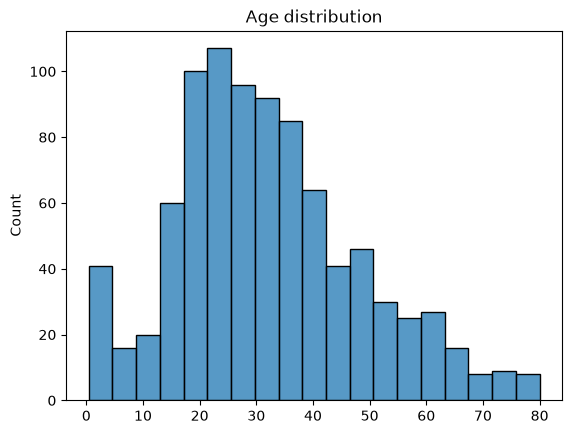

In [12]:
ages = x["Age"].to_numpy()

sns.histplot(ages)
plt.title("Age distribution")
plt.show()

looks good enough, just need to be pulled to the center and be normalized. We do this using z-score normalization

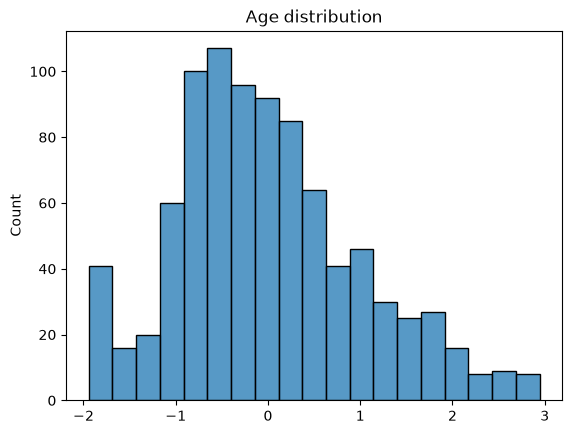

          Age
0   -0.617778
1    0.364968
2   -0.372091
3    0.180703
4    0.180703
..        ...
886 -0.310670
887 -0.802043
888 -1.078440
889 -0.372091
890 -0.003562

[891 rows x 1 columns]


In [13]:
age_mean = ages.mean()
age_std_dev = ages.std()

normalized_ages = []
for age in ages:
    normalized = (age - age_mean) / age_std_dev
    normalized_ages.append(normalized)
    
sns.histplot(normalized_ages)
plt.title("Age distribution")
plt.show()

ages = pd.DataFrame({"Age": normalized_ages})
print(ages)

beauty.. <br>
Lets move to the fare!

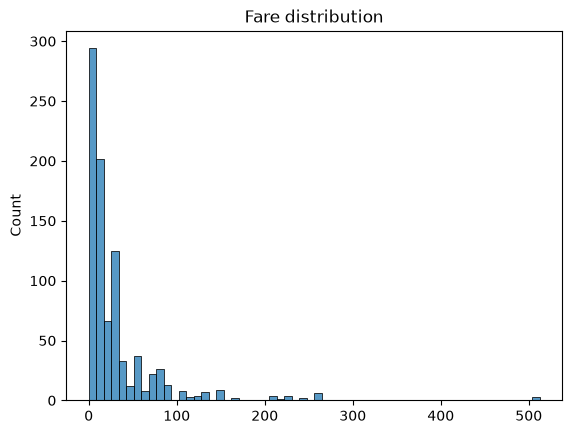

In [14]:
fares = x["Fare"].to_numpy()

sns.histplot(fares)
plt.title("Fare distribution")
plt.show()

oh no.. this fare distribution needs something powerful to pull the outlier back. hmm.. <br>
I'll apply log to each one so that the further the value is, the more it pulled back to the center of the data and apply z-score normalization.

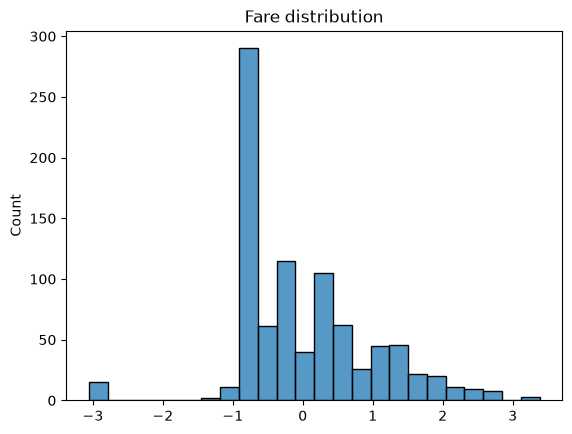

In [15]:
fares = np.log1p(fares)

fares_mean = fares.mean()
fares_std_dev = fares.std()

normalized_fares = []
for fare in fares:
    normalized = (fare - fares_mean) / fares_std_dev
    normalized_fares.append(normalized)    
      
sns.histplot(normalized_fares)
plt.title("Fare distribution")
plt.show()

fares = pd.DataFrame({"Fare": normalized_fares})

phew, better than the above. <br>
Now lets grab the x and y for training

In [16]:
x = pd.concat([
        x[["Sex", "Pclass", "SibSp", "Parch", "Family"]], ages["Age"], fares["Fare"] # type: ignore
    ], axis=1) # type: ignore

print(x)

y = dataset[["Survived"]]

x = x.to_numpy()
y = y.to_numpy()

x = x.astype(np.float32)
y = y.astype(np.float32)

# split data into 2/3 for training and 1/3 for testing
x_train = x[0:math.floor(x.shape[0] / 3 * 2), :].copy()
y_train = y[0:math.floor(y.shape[0] / 3 * 2), :].copy()

x_test = x[math.ceil(x.shape[0] / 3 * 2):x.shape[0], :].copy()
y_test = y[math.ceil(y.shape[0] / 3 * 2):y.shape[0], :].copy()

x_train = torch.from_numpy(x_train)
y_train = torch.from_numpy(y_train)

x_test = torch.from_numpy(x_test)
y_test = torch.from_numpy(y_test)

feature_count = x_train.shape[1]
sample_count = x_train.shape[0]


print(x_train)
print(y_train)

    Sex  Pclass  SibSp  Parch  Family       Age      Fare
0     1       3      1      0       1 -0.617778 -0.879741
1     0       1      1      0       1  0.364968  1.361220
2     0       3      0      0       0 -0.372091 -0.798540
3     0       1      1      0       1  0.180703  1.062038
4     1       3      0      0       0  0.180703 -0.784179
..   ..     ...    ...    ...     ...       ...       ...
886   1       2      0      0       0 -0.310670 -0.333698
887   0       1      0      0       0 -0.802043  0.487082
888   0       3      1      2       3 -1.078440  0.242007
889   1       1      0      0       0 -0.372091  0.487082
890   1       3      0      0       0 -0.003562 -0.818987

[891 rows x 7 columns]
tensor([[ 1.0000,  3.0000,  1.0000,  ...,  1.0000, -0.6178, -0.8797],
        [ 0.0000,  1.0000,  1.0000,  ...,  1.0000,  0.3650,  1.3612],
        [ 0.0000,  3.0000,  0.0000,  ...,  0.0000, -0.3721, -0.7985],
        ...,
        [ 0.0000,  1.0000,  1.0000,  ...,  1.0000,  1.224

### Model Training

i'll Pytorch to build a Logistic Regression model.

In [17]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(feature_count, 1)
        
    def forward(self, x):
        x = self.linear(x)
        return x
    
logisticRegression = LogisticRegression()
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(logisticRegression.parameters(), lr=0.05)

In [18]:
for epoch in range(250):
    logits = logisticRegression(x_train)

    l = loss(logits, y_train)
    l.backward()
    
    optimizer.step()
    optimizer.zero_grad()
    
    if epoch % 20 == 0:
        print(f"epoch {epoch} = loss: {l}")

epoch 0 = loss: 0.7588140368461609
epoch 20 = loss: 0.5332893133163452
epoch 40 = loss: 0.4899600148200989
epoch 60 = loss: 0.474638968706131
epoch 80 = loss: 0.4695294201374054
epoch 100 = loss: 0.4667985141277313
epoch 120 = loss: 0.46468690037727356
epoch 140 = loss: 0.4629244804382324
epoch 160 = loss: 0.46148860454559326
epoch 180 = loss: 0.4603578746318817
epoch 200 = loss: 0.45949438214302063
epoch 220 = loss: 0.4588537812232971
epoch 240 = loss: 0.458391398191452


### Testing Model

i'll run back the training sample and measure the accuracy

In [19]:
sigmoid = nn.Sigmoid()

test_logits = logisticRegression(x_train)
test_logits = sigmoid(test_logits)
test_logits = test_logits.detach().numpy()

model_guess = test_logits.round()

guesses = []
for person in range(test_logits.shape[0]):
    guesses.append(1) if model_guess[person][0] == y_train[person][0] else guesses.append(0)
    
guesses = pd.Series(guesses)

true_guesses = guesses.value_counts()[1]
wrong_guesses = guesses.value_counts()[0]
guesses_count = guesses.count()

accuracy = round((true_guesses / guesses_count) * 100)

print("===========[Train Samples Acurracy]==========")
print(f"Right guesses: {true_guesses}")
print(f"Wrong guesses: {wrong_guesses}")
print(f"Prediction accuracy: {accuracy}%")

===========[Train Samples Acurracy]==========
Right guesses: 473
Wrong guesses: 121
Prediction accuracy: 80%


Now i will test it using the test samples to see if the model performing in an unseen data or if its overfitting or underfitting.

In [20]:
test_logits = logisticRegression(x_test)
test_logits = sigmoid(test_logits)
test_logits = test_logits.detach().numpy()

model_guess = test_logits.round()

guesses = []
for person in range(test_logits.shape[0]):
    guesses.append(1) if model_guess[person][0] == y_test[person][0] else guesses.append(0)
    
guesses = pd.Series(guesses)

true_guesses = guesses.value_counts()[1]
wrong_guesses = guesses.value_counts()[0]
guesses_count = guesses.count()

accuracy = round((true_guesses / guesses_count) * 100)

print("===========[Test Samples Acurracy]==========")
print(f"Right guesses: {true_guesses}")
print(f"Wrong guesses: {wrong_guesses}")
print(f"Prediction accuracy: {accuracy}%")

===========[Test Samples Acurracy]==========
Right guesses: 237
Wrong guesses: 60
Prediction accuracy: 80%


## Test Result
1. First test <br>
<p>log transformation in Fare, and z-score normalization in Fare and Age.</p>
<img src="./images/first_test.png" width="50%"> <br>
- Prediction accuracy (10 tries): 79% - 81% (uniformed) <br>
- 'linear.weight': [-2.6970, -0.8519, -0.1264,  0.1964, -0.2586, -0.5122,  0.0915], 'linear.bias': [3.2855]

2. Second test <br>
<p>log transformation in Fare, and z-score normalization in Fare and Age. Also, compressing every class value range to be approximately the same.</p>
<img src="./images/second_test.png" width="50%"> <br>
- Prediction accuracy (10 tries): 78% - 81% (uniformed)

3. Third test <br>
<p>log transformation and z-score normalization in Fare.</p>
<img src="./images/third_test.png" width="50%"> <br>
- Prediction accuracy (20 tries): 79% 

4. Fourth test <br>
<p>No transformation and normalization made.</p>
<img src="./images/fourth_test.png" width="50%"> <br>
- Prediction accuracy (20 tries): 79% - 80% (hit 80% once) <br>
- 'linear.weight': [-2.4214, -0.2476, -0.3646, -0.0458,  0.0580, -0.0059,  0.0074], 'linear.bias': [1.6092]
<br><br>
In conclusion, the transformation and normalization matter, but all the feature power of the Sex is higher than any of the other feature making the accuracy stay still. 
<br><br>
And that mark the end of our journey with logistic regression because we hit the maximum predictive power of linear model can do.

In [21]:
print(logisticRegression(torch.tensor([[1,1,1,1,1,1,1]], dtype=torch.float32)))

tensor([[-1.1305]], grad_fn=<AddmmBackward0>)


In [22]:
old = [1, 2]

new = old

new.append(20)

print(old)

[1, 2, 20]
